In [1]:
import pandas as pd
import allel
import numpy as np
import seaborn as sns

In [2]:
snps_names = pd.read_csv('../key_files/var_pos_grenenet.csv')

import pickle
with open('../key_files/blocks_snpsid_dict.pkl', 'rb') as f:
    dict_blocks = pickle.load(f)

reverse_mapping = {item: key for key, values in dict_blocks.items() for item in values}

snps_names = snps_names[snps_names['total_alleles05filter_firstgen'].notna()].reset_index(drop=True)

In [3]:
clim1001 = pd.read_csv('../key_files/1001g_regmap_grenet_ecotype_info_corrected_bioclim_2024May16.csv')

clim1001['ecotypeid'] = clim1001['ecotypeid'].astype(str)


In [4]:
clim1001

,Unnamed: 0,ecotypeid,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,...,vapr03,vapr04,vapr05,vapr06,vapr07,vapr08,vapr09,vapr10,vapr11,vapr12
0,1,159,9.325000,7.700000,32.352940,596.430664,22.700001,-1.100000,23.800001,3.216667,...,0.69,0.77,1.05,1.28,1.44,1.45,1.28,1.05,0.77,0.66
1,2,265,12.962500,9.558333,42.293510,483.411774,25.200001,2.600000,22.600000,8.000000,...,0.96,1.01,1.30,1.55,1.82,1.80,1.62,1.34,1.02,0.92
2,3,763,-2.995833,13.675000,29.728262,1198.782471,19.900000,-26.100000,46.000000,8.016666,...,0.25,0.43,0.59,0.73,0.77,0.68,0.49,0.38,0.24,0.15
3,4,765,-2.487500,14.675000,30.829832,1216.552734,21.299999,-26.299999,47.599998,3.550000,...,0.25,0.44,0.61,0.75,0.78,0.68,0.48,0.39,0.24,0.15
4,5,766,-4.283333,13.516666,32.648952,1032.257690,16.900000,-24.500000,41.400002,0.533333,...,0.18,0.35,0.49,0.62,0.65,0.56,0.39,0.31,0.18,0.11
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1866,1867,9482,7.212500,7.408333,30.868055,627.401306,21.100000,-2.900000,24.000000,7.800000,...,0.55,0.67,0.92,1.18,1.43,1.41,1.16,0.91,0.71,0.60
1867,1868,9490,8.733334,7.150000,38.440861,425.015137,19.299999,0.700000,18.599998,12.066667,...,0.72,0.77,0.92,1.11,1.30,1.28,1.13,0.97,0.76,0.70
1868,1869,9496,8.662500,7.108334,38.423424,424.730530,19.200001,0.700000,18.500000,12.016666,...,0.71,0.77,0.92,1.12,1.30,1.28,1.12,0.97,0.76,0.69
1869,1870,9499,8.270833,6.975000,38.114754,422.419739,18.700001,0.400000,18.300001,8.733334,...,0.71,0.74,0.91,1.11,1.28,1.26,1.11,0.95,0.77,0.69


In [5]:
founder_ecotypes = pd.read_csv('../key_files/founder_ecotype_names.csv')['0'].values

In [6]:
vcfgrene = allel.read_vcf('../gwas/greneNet_final_v1.1.recode.vcf.gz')


KeyboardInterrupt



In [ ]:
#vcfgrene = allel.read_vcf('../gwas/1001g/1001g_grenet_climate.recode.vcf')
geno = vcfgrene['calldata/GT']

geno = geno.sum(axis=2)

geno = pd.DataFrame(geno)

geno.columns = vcfgrene['samples']

grene_chrom_pos = pd.DataFrame({'chrom': vcfgrene['variants/CHROM'], 'pos': vcfgrene['variants/POS']})

#vcfgrene = pd.concat([grene_chrom_pos, geno],axis=1)

In [112]:
clim1001['ecotypeid']

0        159
1        265
2        763
3        765
4        766
        ... 
1866    9482
1867    9490
1868    9496
1869    9499
1870    9504
Name: ecotypeid, Length: 1871, dtype: object

array(['10002', '10006', '10011', '10013', '10014', '159', '265', '5151',
       '5165', '5768', '5772', '5784', '5811', '6013', '6025', '6040',
       '6073', '6074', '6108', '6150', '6177', '6180', '6184', '6188',
       '6195', '6209', '6216', '6243', '6244', '6898', '6911', '6915',
       '6929', '6932', '6938', '6940', '6945', '6958', '6961', '6963',
       '6979', '6987', '7000', '7002', '7003', '7008', '7013', '7025',
       '7028', '7031', '7036', '7062', '7063', '7067', '7071', '7077',
       '7092', '7103', '7106', '7125', '7126', '7127', '7143', '7164',
       '7165', '7186', '7203', '7209', '7217', '7218', '7244', '7255',
       '7268', '7273', '7276', '7282', '7287', '7288', '7296', '7298',
       '7316', '7323', '7333', '7346', '7347', '7353', '7372', '7378',
       '7384', '7394', '7404', '7411', '7521', '763', '765', '766', '768',
       '772', '8214', '8230', '8231', '8240', '8247', '8249', '8311',
       '8312', '8351', '8354', '8357', '8376', '8387', '9057', '9058',


In [ ]:
clim1001 = clim1001[clim1001['ecotypeid'].isin(geno.columns)]

In [120]:
clim1001 = clim1001[clim1001['ecotypeid'].isin(founder_ecotypes.astype(str))]

In [121]:
clim1001

,Unnamed: 0,ecotypeid,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,...,vapr03,vapr04,vapr05,vapr06,vapr07,vapr08,vapr09,vapr10,vapr11,vapr12
0,1,159,9.325000,7.700000,32.352940,596.430664,22.700001,-1.100000,23.800001,3.216667,...,0.69,0.77,1.05,1.28,1.44,1.45,1.28,1.05,0.77,0.66
1,2,265,12.962500,9.558333,42.293510,483.411774,25.200001,2.600000,22.600000,8.000000,...,0.96,1.01,1.30,1.55,1.82,1.80,1.62,1.34,1.02,0.92
2,3,763,-2.995833,13.675000,29.728262,1198.782471,19.900000,-26.100000,46.000000,8.016666,...,0.25,0.43,0.59,0.73,0.77,0.68,0.49,0.38,0.24,0.15
3,4,765,-2.487500,14.675000,30.829832,1216.552734,21.299999,-26.299999,47.599998,3.550000,...,0.25,0.44,0.61,0.75,0.78,0.68,0.48,0.39,0.24,0.15
4,5,766,-4.283333,13.516666,32.648952,1032.257690,16.900000,-24.500000,41.400002,0.533333,...,0.18,0.35,0.49,0.62,0.65,0.56,0.39,0.31,0.18,0.11
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
226,227,9977,8.716667,10.466667,36.216839,703.062561,24.200001,-4.700000,28.900002,17.333334,...,0.57,0.68,1.01,1.22,1.47,1.41,1.19,0.83,0.57,0.42
227,228,9992,9.887500,10.158334,28.941122,912.989929,29.299999,-5.800000,35.099998,3.016667,...,0.49,0.70,0.90,0.99,1.11,1.04,0.84,0.75,0.58,0.44
228,229,100001,15.829166,11.858334,40.334469,684.684570,31.500000,2.100000,29.400000,7.166667,...,0.73,0.80,0.91,1.09,1.32,1.40,1.25,1.05,0.84,0.74
229,230,100002,15.100000,11.616667,39.919815,682.748474,30.500000,1.400000,29.100000,6.450000,...,0.69,0.75,0.86,1.01,1.23,1.32,1.17,0.99,0.80,0.71


In [122]:
clim1001 = clim1001[['ecotypeid', 'bio1']]

In [123]:
clim1001['ecotypeid'] = clim1001['ecotypeid'].astype(str)

/tmp/ipykernel_649045/689236628.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  clim1001['ecotypeid'] = clim1001['ecotypeid'].astype(str)


In [124]:
clim1001_dict = clim1001.set_index('ecotypeid')['bio1'].to_dict()

In [125]:
len(clim1001_dict)

231

In [ ]:
geno.columns

In [126]:
clim1001 = clim1001.set_index('ecotypeid')

In [127]:
clim1001


,bio1
ecotypeid,
159,9.325000
265,12.962500
763,-2.995833
765,-2.487500
766,-4.283333
...,...
9977,8.716667
9992,9.887500
100001,15.829166


In [ ]:
geno = geno.T

In [ ]:
geno = geno.sort_index()

In [ ]:
order_ecotypes = geno.index

In [128]:
clim1001 = clim1001.sort_index()

In [ ]:
geno = geno.reset_index(drop=True)

In [129]:
clim1001 = clim1001.reset_index(drop=True)

In [130]:
np.mean(clim1001)


9.584559885454384

In [ ]:
#unique, counts = np.unique(geno, return_counts=True)  # array([666040577,     40258,  81315045])

In [ ]:
#geno = np.where(geno == 0, -1, geno)  # Replace 0 with -1
#geno = np.where(geno == 2, 1, geno)  # Replace 2 with 1
#geno = np.where(geno == 1, 0, geno)  # Replace 1

In [ ]:
clim1001 = np.array(clim1001)

temperature_centered = clim1001 - np.mean(clim1001)

snp_temperature_association = np.array(geno).T.dot(np.array(temperature_centered))

snp_temperature_association /= len(clim1001)

snp_temperature_association = pd.Series(snp_temperature_association.flatten())

<Axes: ylabel='Count'>

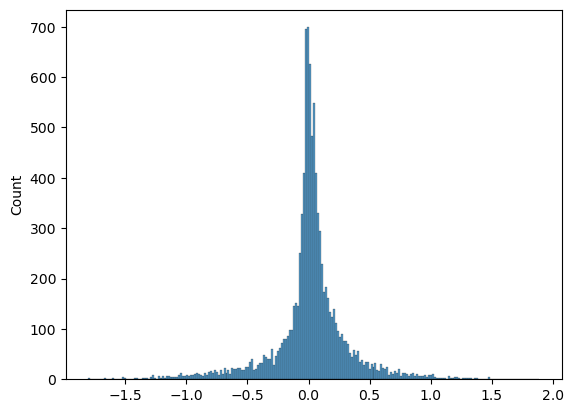

In [79]:
sns.histplot(pd.Series(snp_temperature_association).sample(10000))

In [ ]:
np.mean(clim1001)

In [80]:
snp_origin_bio1 = pd.DataFrame({'chrom': vcfgrene['variants/CHROM'], 'pos': vcfgrene['variants/POS'], 'snp_origin_bio1': snp_temperature_association})

In [23]:
#snp_origin_bio1.to_csv('../key_files/snp_origin_bio1_1001gvcf.csv',index=None)

In [23]:
#grene_chrom_pos.sort_values('snp_origin_bio1')

In [82]:
#snp_origin_bio1.to_csv('../key_files/snp_origin_bio1_grenenetvcf.csv',index=None)

In [ ]:
## approxiamtion of block orgins 

In [152]:
snp_origin_bio1['id'] = snp_origin_bio1['chrom'].astype(str) + '_' + snp_origin_bio1['pos'].astype(str)

In [153]:
snp_origin_bio1['blocks'] = snp_origin_bio1['id'].map(reverse_mapping)

In [155]:
snp_origin_bio1

,id,chrom,pos,snp_origin_bio1,blocks
0,1_291,1,291,9.796649,1_0
1,1_346,1,346,9.076162,1_0
2,1_349,1,349,9.587698,1_0
3,1_352,1,352,9.592687,1_0
4,1_353,1,353,9.799416,1_0
...,...,...,...,...,...
3235475,5_26975208,5,26975208,9.583726,5_3110
3235476,5_26975215,5,26975215,9.610140,5_3110
3235477,5_26975267,5,26975267,9.591209,5_3110
3235478,5_26975272,5,26975272,10.235262,5_3110


In [156]:
block_origin_bio1 = snp_origin_bio1.groupby('blocks')['snp_origin_bio1'].mean().reset_index()

In [157]:
#block_origin_bio1.to_csv('../key_files/block_origin_bio1_grenenetvcf_ogscale.csv',index=None)

In [7]:
snp_origin_bio1 = pd.read_csv('../key_files/snp_origin_bio1_1001gvcf.csv')

dict_snps = pd.read_csv('../key_files/var_pos_grenenet.csv')

snp_origin_bio1 = pd.concat([dict_snps['id'], snp_origin_bio1],axis=1)

In [8]:
snp_origin_bio1['snp_origin_bio1'] = snp_origin_bio1['snp_origin_bio1'] + 9.584559885454384

In [9]:
snp_origin_bio1

,id,chrom,pos,snp_origin_bio1
0,1_291,1,291,9.796649
1,1_346,1,346,9.076162
2,1_349,1,349,9.587698
3,1_352,1,352,9.592687
4,1_353,1,353,9.799416
...,...,...,...,...
3235475,5_26975208,5,26975208,9.583726
3235476,5_26975215,5,26975215,9.610140
3235477,5_26975267,5,26975267,9.591209
3235478,5_26975272,5,26975272,10.235262


In [13]:
binomial_reg = pd.read_csv('../binomial_regression_lastgen/binomial_reg_lastgen_wmaf_bio1.csv')

In [14]:
#binomial_reg = pd.read_csv('../binomial_regression_lastgen/binomial_reg_results_last_gen.csv')

binomial_reg_id = dict_snps[dict_snps['total_alleles05filter_lastgen'].notna()]['id'].reset_index(drop=True)

binomial_reg = pd.concat([binomial_reg, binomial_reg_id],axis=1)

snp_origin_beta_binomial_reg = snp_origin_bio1.merge(binomial_reg)

<Axes: xlabel='slope', ylabel='Count'>

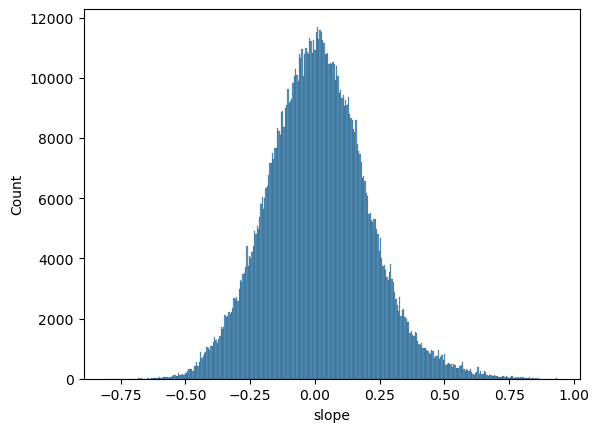

In [11]:
sns.histplot(snp_origin_beta_binomial_reg['slope'])

<Axes: xlabel='snp_origin_bio1', ylabel='slope'>

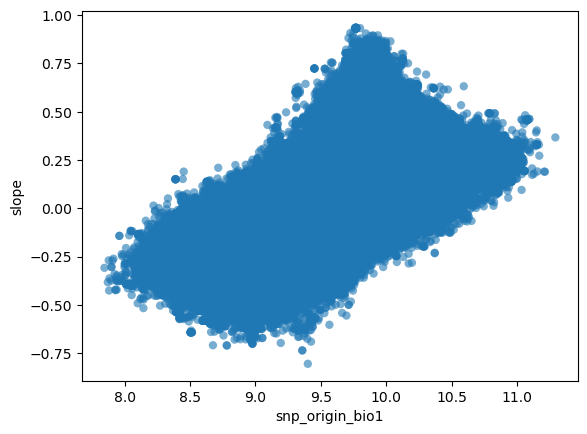

In [17]:



sns.scatterplot(
    data=snp_origin_beta_binomial_reg,
    x='snp_origin_bio1',
    y='
    ',
    edgecolor="none",  # Remove white edge around the dots
    alpha=0.6,  # Set transparency
    legend=None
)



In [23]:
#### calcualte teh correlation on ld pruned allele

vcfgrene = allel.read_vcf('../key_files/greneNet_final_v1.1_LDpruned.recode.vcf')

In [28]:
variants_ld_prunned = vcfgrene['variants/ID']

In [32]:
snp_origin_beta_binomial_reg_ldp = snp_origin_beta_binomial_reg[snp_origin_beta_binomial_reg['id'].isin(variants_ld_prunned)]

In [33]:
from scipy.stats import pearsonr
correlation, p_value = pearsonr(snp_origin_beta_binomial_reg_ldp['snp_origin_bio1'], snp_origin_beta_binomial_reg_ldp['slope'])

In [34]:
correlation

0.49832894777515324

In [35]:
p_value

0.0

In [36]:
len(snp_origin_beta_binomial_reg_ldp)

13625

In [ ]:
import matplotlib.pyplot as plt

In [138]:
0.05/len(snp_origin_beta_binomial_reg)

4.768103296189809e-08

In [139]:
sign = snp_origin_beta_binomial_reg[snp_origin_beta_binomial_reg['pvalue'] < 4.768103296189809e-08]

In [140]:
sign['log_pvalue'] = np.log(sign['pvalue'])

/home/tbellagio/miniforge3/envs/pipeline_snakemake/lib/python3.9/site-packages/pandas/core/arraylike.py:396: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/tmp/ipykernel_649045/3637229368.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sign['log_pvalue'] = np.log(sign['pvalue'])


In [141]:
sign

,id,chrom,pos,snp_origin_bio1,snp_origin_bio1_back,slope,pvalue,snp_id,log_pvalue
3,1_395,1,395,9.859109,9.859109,0.588284,2.536460e-138,1_395,-316.825974
4,1_396,1,396,9.859109,9.859109,0.588284,2.536460e-138,1_396,-316.825974
7,1_465,1,465,9.875243,9.875243,0.657404,8.407327e-177,1_465,-405.428458
10,1_508,1,508,9.505349,9.505349,0.211540,3.819442e-37,1_508,-83.855544
11,1_643,1,643,9.793115,9.793115,0.372599,6.959796e-73,1_643,-166.148562
...,...,...,...,...,...,...,...,...,...
1048625,5_26974485,5,26974485,9.628015,9.628015,-0.219671,1.329228e-17,5_26974485,-38.859348
1048629,5_26975046,5,26975046,9.510938,9.510938,-0.194857,1.249174e-39,5_26975046,-89.578336
1048630,5_26975078,5,26975078,9.018482,9.018482,-0.291705,1.978042e-74,5_26975078,-169.709189
1048633,5_26975272,5,26975272,10.235262,10.235262,0.085222,5.859110e-12,5_26975272,-25.863023


In [11]:
snp_origin_beta_binomial_reg

NameError: name 'snp_origin_beta_binomial_reg' is not defined

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

import statsmodels.api as sm

In [143]:
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42 

In [144]:
import matplotlib.colors as mcolors
font_size = 12

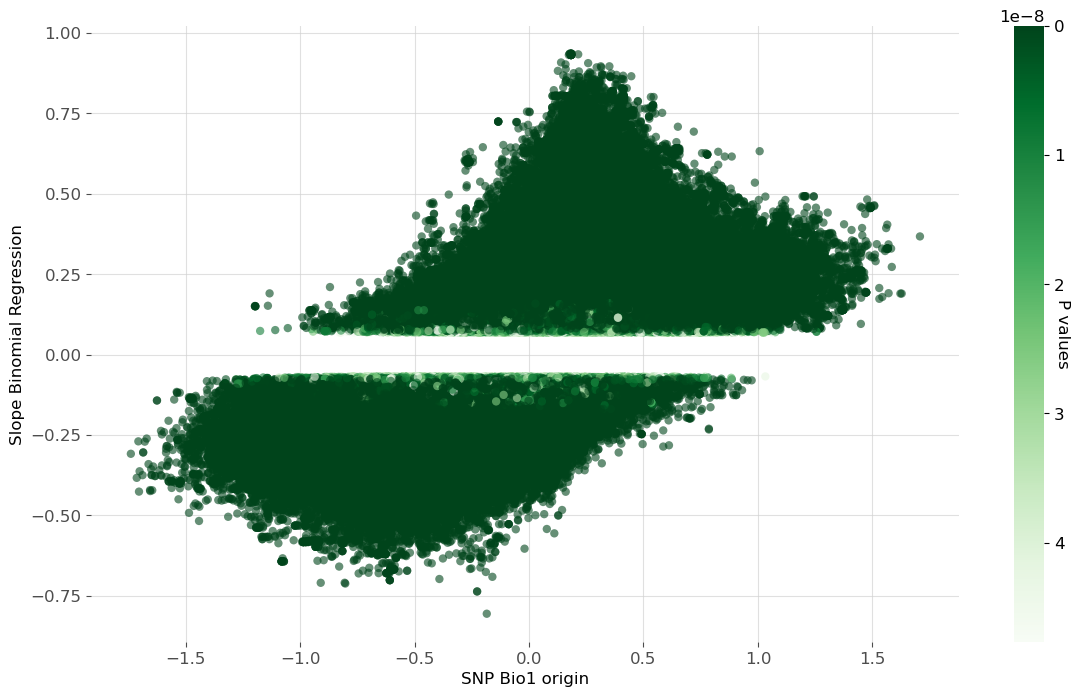

In [13]:
# Assuming snp_origin_beta_binomial_reg is your DataFrame with SNP data
# Create a scatter plot using density for color
fig, ax = plt.subplots(figsize=(14, 8))

sns.scatterplot(
    data=sign,
    x='snp_origin_bio1',
    y='slope',
    hue='pvalue',  # Use the density as color
    palette="Greens_r",  # Color mapping
    edgecolor="none",  # Remove white edge around the dots
    alpha=0.6,  # Set transparency
    ax=ax,
    legend=None
)

# Plot the regression line using seaborn
#sns.regplot(data=sign,
#    x='snp_origin_bio1',
#    y='slope',
#    scatter=False,  # Do not plot the scatter again
#    line_kws={"color": "green", "alpha": 0.7},  # Customize the regression line
#    ax=ax,
#    ci=None,  # Disable confidence interval
#)

plt.ylabel('Slope Binomial Regression')
plt.xlabel('SNP Bio1 origin')
plt.rcParams['axes.axisbelow'] = True


# Create a color normalization object for the p-values
norm = mcolors.Normalize(vmin=sign['pvalue'].min(), vmax=sign['pvalue'].max())
sm = plt.cm.ScalarMappable(cmap="Greens_r", norm=norm)
sm.set_array([])  # Only needed for older versions of matplotlib

# Add the color bar with reduced size and no borders
cbar = plt.colorbar(sm, ax=ax,)  # Adjust shrink value to make it smaller
cbar.set_label('P values', rotation=270)
cbar.ax.invert_yaxis()  # Invert the color bar if needed
cbar.outline.set_visible(False)  # Remove border outline
#cbar.ax.set_position([0.8, 0.1, 0.02, 0.5])  # [left, bottom, width, height]


# Annotate the plot with slope, p-value, and R-squared
#if p_value < 1e-6:
#    p_value_text = "p ≈ 0"
#else:
#    p_value_text = f'P-value: {p_value:.3g}'

## Add the text box for the regression line info
#plt.text(
#    0.05, 0.9,  # X and Y position for annotation
#    f'Slope: {slope:.3f}\n{p_value_text}\n$R^2$: {r_squared:.3f}',  # Annotation text
#    fontsize=12, color="black",  # Font properties
#    ha='left', va='top',  # Text alignment
#    transform=ax.transAxes  # Ensure it's positioned relative to the axes
#)

#plt.rc('font', family='sans-serif', size=font_size)  # Regular font size
#plt.rc('axes', titlesize=font_size, labelsize=font_size)  # Title and label size for axes
#plt.rc('xtick', labelsize=font_size)  # X tick labels size
#plt.rc('ytick', labelsize=font_size)  # Y tick labels size

dark_grey = '#4D4D4D'  # Define dark grey color
plt.grid(True, color='lightgrey', alpha=0.7,  zorder=0) # linewidth=1.5,

# Apply to spines
plt.gca().spines['left'].set_visible(False)
plt.gca().spines['bottom'].set_visible(False)
plt.gca().spines['top'].set_visible(False)

plt.gca().spines['right'].set_visible(False)

# Set tick parameters
plt.tick_params(axis='both', colors=dark_grey)  # Set tick colors
#plt.savefig('snps_origin_Vs_slopebr.png')
#plt.savefig('snps_origin_Vs_slopebr.pdf')
# Display the plot
plt.show()


In [ ]:
## launc wza on the binomial reg across sites 

In [37]:
wza_binomial_regression_bio1 = pd.read_csv('../wza_last_gen/wza_binomial_regression_bio1_poly7.csv')

In [38]:
dict_snps = pd.read_csv('../key_files/var_pos_grenenet.csv')

In [39]:
block_origin_bio1 = pd.read_csv('../key_files/block_origin_bio1_grenenetvcf_ogscale.csv')

In [42]:
# get the slope from the binomial reg 
binomial_reg = pd.read_csv('../binomial_regression_lastgen/binomial_reg_lastgen_wmaf_bio1.csv')

binomial_reg_id = dict_snps[dict_snps['total_alleles05filter_lastgen'].notna()]['id'].reset_index(drop=True)

binomial_reg = pd.concat([binomial_reg, binomial_reg_id],axis=1)

binomial_reg['block'] = binomial_reg['id'].map(reverse_mapping)

binomial_reg = binomial_reg.groupby('block')['slope'].mean().reset_index()


In [43]:
wza_binomial_regression_bio1 = wza_binomial_regression_bio1.merge(binomial_reg, left_on = 'gene', right_on = 'block')

In [44]:
wza_binomial_regression_bio1 = wza_binomial_regression_bio1.merge(block_origin_bio1, left_on = 'block', right_on = 'blocks')

In [50]:
wza_binomial_regression_bio1

,gene,SNPs,hits,Z,top_candidate_p,Z_pVal,block_x,slope,blocks,snp_origin_bio1,block_y,model,gen
0,1_0,206,1,-2.717010,0.873861,0.646712,1_0,0.117863,1_0,9.557697,NaN,NaN,NaN
1,1_1,3,0,1.435811,1.000000,0.109097,1_1,0.300998,1_1,9.586540,NaN,NaN,NaN
2,1_10,22,0,2.870291,1.000000,0.106855,1_10,0.252985,1_10,9.658528,NaN,NaN,NaN
3,1_100,51,0,-0.630866,1.000000,0.533371,1_100,-0.067911,1_100,9.550711,NaN,NaN,NaN
4,1_1000,9,0,2.280958,1.000000,0.074280,1_1000,-0.226046,1_1000,9.356437,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
16624,5_995,36,0,-1.970640,1.000000,0.700093,5_995,0.027870,5_995,9.628372,NaN,NaN,NaN
16625,5_996,3,0,1.153428,1.000000,0.154236,5_996,0.302738,5_996,9.610381,NaN,NaN,NaN
16626,5_997,27,0,-1.042048,1.000000,0.611025,5_997,0.107538,5_997,9.600728,NaN,NaN,NaN
16627,5_998,6,0,-1.915530,1.000000,0.868103,5_998,0.032577,5_998,9.576123,NaN,NaN,NaN


In [45]:
sign_blocks_all = pd.read_csv('../signficant_intersection/sign_blocks_union_first_last_gen_BH_final.csv')

In [ ]:
sign_blocks_all

In [46]:
sign_blocks_all['gen'].unique()

array(['first_gen', 'first_gen,last_gen', 'last_gen'], dtype=object)

In [47]:
sign_blocks_all = sign_blocks_all[sign_blocks_all['gen'].isin(['first_gen,last_gen', 'last_gen'])]

In [48]:
wza_binomial_regression_bio1 = wza_binomial_regression_bio1.merge(sign_blocks_all, left_on = 'gene', right_on = 'block',how ='outer')

In [49]:
wza_binomial_regression_bio1

,gene,SNPs,hits,Z,top_candidate_p,Z_pVal,block_x,slope,blocks,snp_origin_bio1,block_y,model,gen
0,1_0,206,1,-2.717010,0.873861,0.646712,1_0,0.117863,1_0,9.557697,NaN,NaN,NaN
1,1_1,3,0,1.435811,1.000000,0.109097,1_1,0.300998,1_1,9.586540,NaN,NaN,NaN
2,1_10,22,0,2.870291,1.000000,0.106855,1_10,0.252985,1_10,9.658528,NaN,NaN,NaN
3,1_100,51,0,-0.630866,1.000000,0.533371,1_100,-0.067911,1_100,9.550711,NaN,NaN,NaN
4,1_1000,9,0,2.280958,1.000000,0.074280,1_1000,-0.226046,1_1000,9.356437,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
16624,5_995,36,0,-1.970640,1.000000,0.700093,5_995,0.027870,5_995,9.628372,NaN,NaN,NaN
16625,5_996,3,0,1.153428,1.000000,0.154236,5_996,0.302738,5_996,9.610381,NaN,NaN,NaN
16626,5_997,27,0,-1.042048,1.000000,0.611025,5_997,0.107538,5_997,9.600728,NaN,NaN,NaN
16627,5_998,6,0,-1.915530,1.000000,0.868103,5_998,0.032577,5_998,9.576123,NaN,NaN,NaN


In [15]:
import pandas as pd
import numpy as np

# Define the colors
lfmm_color = "#DBD56E"  # LFMM color
binom_reg_color = "#A2B062"  # Binomial Regression color
kendall_color = "#688B55"  # Kendall color
# Combination colors
lfmm_binom_color = "#DDA77E"  # LFMM + Binomial Regression
lfmm_kendall_color = "#CC7B3E"  # LFMM + Kendall
binom_kendall_color = "#915527"  # Binomial Regression + Kendall
all_combined_color = "#E76D83"  # Dark grey for all three models combined
default_grey = "grey"  # Default grey if no models present

# Function to assign colors based on the presence of specific models
def assign_color(model_value):
    if isinstance(model_value, str):  # Check if the value is a string
        colors = []
        # Check for each model and assign base colors
        if 'lfmm_l' in model_value:
            colors.append('lfmm')
        if 'binom_reg_l' in model_value:
            colors.append('binom_reg')
        if 'kendall_l' in model_value:
            colors.append('kendall')

        # Combine the colors based on the combinations you defined
        if len(colors) == 1:
            if 'lfmm' in colors:
                return lfmm_color
            elif 'binom_reg' in colors:
                return binom_reg_color
            elif 'kendall' in colors:
                return kendall_color
        elif len(colors) == 2:
            if 'lfmm' in colors and 'binom_reg' in colors:
                return lfmm_binom_color  # LFMM + Binomial Regression
            elif 'lfmm' in colors and 'kendall' in colors:
                return lfmm_kendall_color  # LFMM + Kendall
            elif 'binom_reg' in colors and 'kendall' in colors:
                return binom_kendall_color  # Binomial Regression + Kendall
        elif len(colors) == 3:
            return all_combined_color  # Dark grey for all three models present
    return default_grey  # Default grey if none of the models are present or NaN

# Apply the function to the 'model' column and create a new 'color' column
wza_binomial_regression_bio1['color'] = wza_binomial_regression_bio1['model'].apply(assign_color)

# Display the updated DataFrame

In [16]:
# Split the data into two groups: significant and non-significant
significant = wza_binomial_regression_bio1[wza_binomial_regression_bio1['color'] != 'grey']
non_significant = wza_binomial_regression_bio1[wza_binomial_regression_bio1['color'] == 'grey']

In [17]:
paleta = list(significant['color'].unique())

/tmp/ipykernel_1427861/187083452.py:17: UserWarning: Ignoring `ax`; jointplot is a figure-level function.
  sns.jointplot(


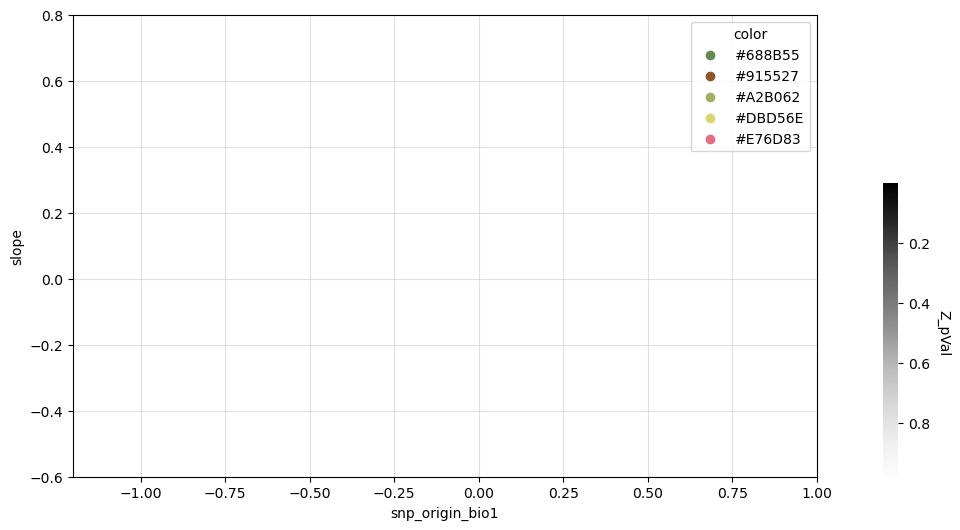

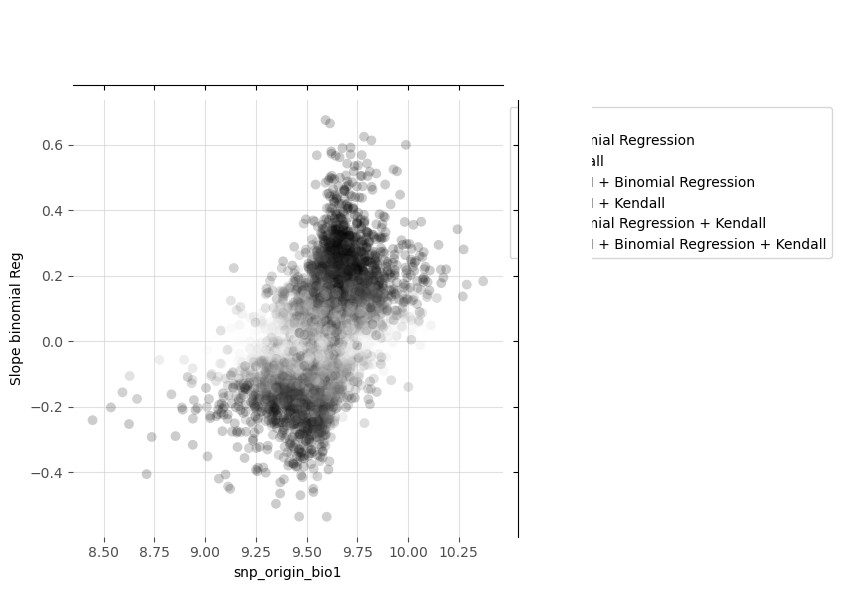

In [18]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
plt.rcParams['axes.axisbelow'] = True
# Example DataFrames (for illustration purposes)
# non_significant = pd.DataFrame({'snp_origin_bio1': [...], 'slope': [...], 'Z_pVal': [...]})
# significant = pd.DataFrame({'snp_origin_bio1': [...], 'slope': [...], 'color': [...]})

fig, ax = plt.subplots(figsize=(12, 6))

# Set grid to be behind scatterplot
plt.grid(True, color='lightgrey', alpha=0.7, zorder=0)

# First, plot non-significant points (grey dots)
sns.jointplot(
    data=non_significant,
    x='snp_origin_bio1',
    y='slope',
    hue='Z_pVal',  # Use the density as color
    palette="Greys_r",  # Color mapping
    s=50,  # Size for non-significant points
    edgecolor="none",  # Remove white edge around the dots
    alpha=0.2,  # Transparency for non-significant points
    ax=ax,
    zorder=1  # Higher zorder to ensure it's on top of the grid
)

# Then, plot significant points (red dots) on top
sns.scatterplot(
    data=significant,
    x='snp_origin_bio1',
    y='slope',
    palette=paleta ,  # Custom colors for significant points
    hue='color',  # Color for significant points
    s=100,  # Larger size for significant points
    edgecolor="none",  # Remove white edge around the dots
    alpha=1,  # Full opacity for significant points
    ax=ax,
    zorder=2  # Even higher zorder to ensure it's on top of non-significant points
)

# Set the x and y limits
ax.set_xlim([-1.2, 1])
ax.set_ylim([-0.6, 0.8])

plt.ylabel('Slope binomial Reg')

# Create a color normalization object for the p-values
norm = mcolors.Normalize(vmin=non_significant['Z_pVal'].min(), vmax=non_significant['Z_pVal'].max())
sm = plt.cm.ScalarMappable(cmap="Greys_r", norm=norm)
sm.set_array([])  # Only needed for older versions of matplotlib

# Add the color bar with reduced size and no borders
cbar = plt.colorbar(sm, ax=ax, shrink=0.8)  # Adjust shrink value to make it smaller
cbar.set_label('Z_pVal', rotation=270, labelpad=15)
cbar.ax.invert_yaxis()  # Invert the color bar if needed
cbar.outline.set_visible(False)  # Remove border outline
cbar.ax.set_position([0.8, 0.1, 0.02, 0.5])  # [left, bottom, width, height]

# Create a custom legend
handles = [
    # Individual models
    plt.Line2D([0], [0], marker='o', color='w', label='LFMM', markerfacecolor=lfmm_color, markersize=10),
    plt.Line2D([0], [0], marker='o', color='w', label='Binomial Regression', markerfacecolor=binom_reg_color, markersize=10),
    plt.Line2D([0], [0], marker='o', color='w', label='Kendall', markerfacecolor=kendall_color, markersize=10),
    # Combinations of two models
    plt.Line2D([0], [0], marker='o', color='w', label='LFMM + Binomial Regression', markerfacecolor=lfmm_binom_color, markersize=10),
    plt.Line2D([0], [0], marker='o', color='w', label='LFMM + Kendall', markerfacecolor=lfmm_kendall_color, markersize=10),
    plt.Line2D([0], [0], marker='o', color='w', label='Binomial Regression + Kendall', markerfacecolor=binom_kendall_color, markersize=10),

    # All three models
    plt.Line2D([0], [0], marker='o', color='w', label='LFMM + Binomial Regression + Kendall', markerfacecolor=all_combined_color, markersize=10),
]


plt.rc('font', family='sans-serif', size=10, weight='normal')  # Regular font size
plt.rc('axes', titlesize=8, labelsize=7)  # Title and label size for axes
plt.rc('xtick', labelsize=7)  # X tick labels size
plt.rc('ytick', labelsize=7)  # Y tick labels size

dark_grey = '#4D4D4D'  # Define dark grey color
plt.grid(True, color='lightgrey', alpha=0.7, zorder=0)

# Apply to spines
plt.gca().spines['left'].set_visible(False)
plt.gca().spines['bottom'].set_visible(False)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

# Set tick parameters
plt.tick_params(axis='both', colors=dark_grey)  # Set tick colors

plt.legend(handles=handles, loc='upper left', bbox_to_anchor=(1, 1))


#plt.savefig("blocks_Across_space_wsign_blocks.png")  # Save as SVG
#plt.savefig("blocks_Across_space_wsign_blocks.svg", format='svg')  # Save as SVG
# Save and show the plot
# plt.savefig('snp_origin_across_space_alpha_size_significant_layered.png')
plt.show()


In [19]:
wza_binomial_regression_bio1[wza_binomial_regression_bio1['Z_pVal']< 0.05/len(wza_binomial_regression_bio1)]

,gene,SNPs,hits,Z,top_candidate_p,Z_pVal,block_x,slope,blocks,snp_origin_bio1,block_y,model,gen,color
128,1_1113,8,8,9.058197,1.000000e-16,1.223877e-08,1_1113,0.673593,1_1113,9.804938,1_1113,"wza_binom_reg_f,wza_kendall_l,wza_binom_reg_l","first_gen,last_gen",#915527
746,1_168,598,310,41.141096,0.000000e+00,2.240255e-06,1_168,0.281196,1_168,9.748046,1_168,"wza_binom_reg_f,wza_binom_reg_l","first_gen,last_gen",#A2B062
16370,5_758,8,8,7.371096,1.000000e-16,2.534549e-06,5_758,0.626856,5_758,9.803522,5_758,"wza_binom_reg_f,wza_binom_reg_l","first_gen,last_gen",#A2B062


In [20]:
wza_binomial_regression_bio1['Z_pVal_log10'] = -np.log10(wza_binomial_regression_bio1['Z_pVal'])

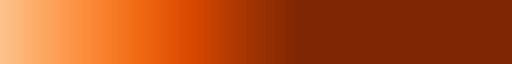

In [21]:
import matplotlib.colors as mcolors

cmap = plt.cm.Oranges(np.linspace(0.3, 1.5, 256))  # start from 30% into the Greens colormap
new_cmap = mcolors.LinearSegmentedColormap.from_list('truncated_greens', cmap)

new_cmap

In [22]:
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42 

In [23]:
sign = pd.read_csv('../signficant_intersection/genes_info_BH_tair10.csv')

sign = sign[sign['gen']!='first_gen']

sign = sign.drop_duplicates('block_id')

In [24]:
wza_binomial_regression_bio1['sign'] = False

In [25]:
wza_binomial_regression_bio1.loc[wza_binomial_regression_bio1['gene'].isin(sign['block_id']), 'sign'] = True

In [26]:
wza_binomial_regression_bio1

,gene,SNPs,hits,Z,top_candidate_p,Z_pVal,block_x,slope,blocks,snp_origin_bio1,block_y,model,gen,color,Z_pVal_log10,sign
0,1_0,206,1,-2.717010,0.873861,0.646712,1_0,0.117863,1_0,9.557697,NaN,NaN,NaN,grey,0.189289,False
1,1_1,3,0,1.435811,1.000000,0.109097,1_1,0.300998,1_1,9.586540,NaN,NaN,NaN,grey,0.962186,False
2,1_10,22,0,2.870291,1.000000,0.106855,1_10,0.252985,1_10,9.658528,NaN,NaN,NaN,grey,0.971206,False
3,1_100,51,0,-0.630866,1.000000,0.533371,1_100,-0.067911,1_100,9.550711,NaN,NaN,NaN,grey,0.272970,False
4,1_1000,9,0,2.280958,1.000000,0.074280,1_1000,-0.226046,1_1000,9.356437,NaN,NaN,NaN,grey,1.129131,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16624,5_995,36,0,-1.970640,1.000000,0.700093,5_995,0.027870,5_995,9.628372,NaN,NaN,NaN,grey,0.154844,False
16625,5_996,3,0,1.153428,1.000000,0.154236,5_996,0.302738,5_996,9.610381,NaN,NaN,NaN,grey,0.811815,False
16626,5_997,27,0,-1.042048,1.000000,0.611025,5_997,0.107538,5_997,9.600728,NaN,NaN,NaN,grey,0.213941,False
16627,5_998,6,0,-1.915530,1.000000,0.868103,5_998,0.032577,5_998,9.576123,NaN,NaN,NaN,grey,0.061429,False


In [27]:
wza_binomial_regression_bio1 = wza_binomial_regression_bio1.merge(sign, left_on='gene', right_on = 'block_id', how='outer')

In [28]:
wza_binomial_regression_bio1

,gene,SNPs,hits,Z,top_candidate_p,Z_pVal,block_x,slope,blocks,snp_origin_bio1,...,gen_x,color,Z_pVal_log10,sign,block_id,model_y,gen_y,source,gene_name,description
0,1_0,206,1,-2.717010,0.873861,0.646712,1_0,0.117863,1_0,9.557697,...,NaN,grey,0.189289,False,NaN,NaN,NaN,NaN,NaN,NaN
1,1_1,3,0,1.435811,1.000000,0.109097,1_1,0.300998,1_1,9.586540,...,NaN,grey,0.962186,False,NaN,NaN,NaN,NaN,NaN,NaN
2,1_10,22,0,2.870291,1.000000,0.106855,1_10,0.252985,1_10,9.658528,...,NaN,grey,0.971206,False,NaN,NaN,NaN,NaN,NaN,NaN
3,1_100,51,0,-0.630866,1.000000,0.533371,1_100,-0.067911,1_100,9.550711,...,NaN,grey,0.272970,False,NaN,NaN,NaN,NaN,NaN,NaN
4,1_1000,9,0,2.280958,1.000000,0.074280,1_1000,-0.226046,1_1000,9.356437,...,NaN,grey,1.129131,False,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16624,5_995,36,0,-1.970640,1.000000,0.700093,5_995,0.027870,5_995,9.628372,...,NaN,grey,0.154844,False,NaN,NaN,NaN,NaN,NaN,NaN
16625,5_996,3,0,1.153428,1.000000,0.154236,5_996,0.302738,5_996,9.610381,...,NaN,grey,0.811815,False,NaN,NaN,NaN,NaN,NaN,NaN
16626,5_997,27,0,-1.042048,1.000000,0.611025,5_997,0.107538,5_997,9.600728,...,NaN,grey,0.213941,False,NaN,NaN,NaN,NaN,NaN,NaN
16627,5_998,6,0,-1.915530,1.000000,0.868103,5_998,0.032577,5_998,9.576123,...,NaN,grey,0.061429,False,NaN,NaN,NaN,NaN,NaN,NaN


In [32]:
wza_binomial_regression_bio1.columns

Index(['gene', 'SNPs', 'hits', 'Z', 'top_candidate_p', 'Z_pVal', 'block_x',
       'slope', 'blocks', 'snp_origin_bio1', 'block_y', 'model_x', 'gen_x',
       'color', 'Z_pVal_log10', 'sign', 'block_id', 'model_y', 'gen_y',
       'source', 'gene_name', 'description'],
      dtype='object')

<Axes: xlabel='snp_origin_bio1', ylabel='slope'>

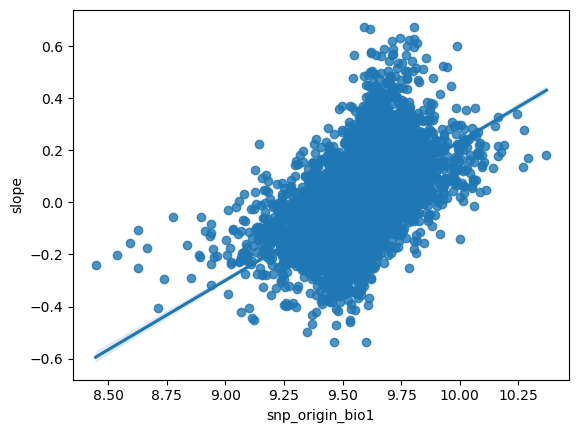

In [51]:
sns.regplot(data = wza_binomial_regression_bio1, x = 'snp_origin_bio1', y = 'slope')

In [35]:
X 

0        9.557697
1        9.586540
2        9.658528
3        9.550711
4        9.356437
           ...   
16624    9.628372
16625    9.610381
16626    9.600728
16627    9.576123
16628    9.651102
Name: snp_origin_bio1, Length: 16629, dtype: float64

In [52]:
import statsmodels.api as sm_api  # Use a clear alias

# Fit a regression model using statsmodels
X = wza_binomial_regression_bio1['snp_origin_bio1']
y = wza_binomial_regression_bio1['slope']

# Add constant (intercept) for statsmodels
X_with_intercept = sm_api.add_constant(X)  # Use the clear alias

# Fit the model
model = sm_api.OLS(y, X_with_intercept).fit()  # Use the clear alias

# Extract slope, p-value, and R-squared values
slope = model.params[1]
intercept = model.params[0]
p_value = model.pvalues[1]
r_squared = model.rsquared

print(slope, intercept, p_value, r_squared)

0.5329184609370705 -5.0953642278849705 0.0 0.24158473914009915


In [ ]:
from scipy.stats import pearsonr

correlation, p_value = pearsonr(merged['slope_site5'], merged['slope_site25'])

In [ ]:
len(wza_binomial_regression_bio1)

In [42]:
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  slope   R-squared:                       0.242
Model:                            OLS   Adj. R-squared:                  0.242
Method:                 Least Squares   F-statistic:                     5296.
Date:                Sun, 15 Dec 2024   Prob (F-statistic):               0.00
Time:                        07:47:45   Log-Likelihood:                 14183.
No. Observations:               16629   AIC:                        -2.836e+04
Df Residuals:                   16627   BIC:                        -2.835e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
===================================================================================
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const              -5.0954      0.070    -72.626      0.000      -5.233      -4.958
snp_origin_bio1     0.5329      0.007     72.776      0.000       0.519       0.547
==============================================================================
Omnibus:                     1352.260   Durbin-Watson:                   1.667
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             3665.616
Skew:                           0.460   Prob(JB):                         0.00
Kurtosis:                       5.108   Cond. No.                         850.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

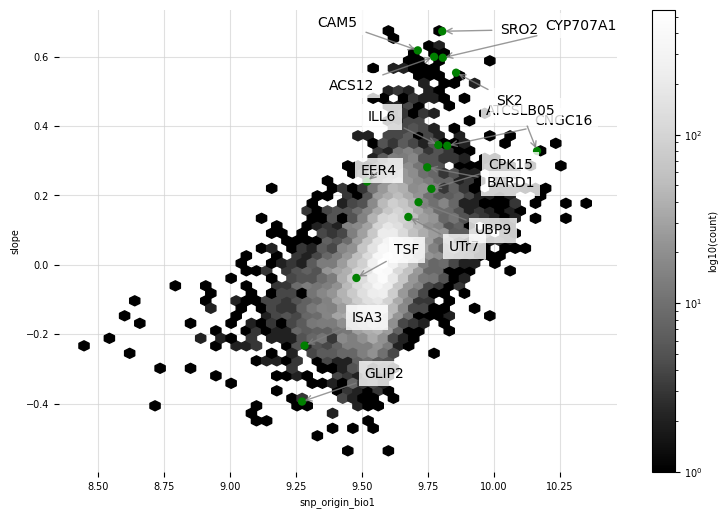

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from adjustText import adjust_text

fig, ax = plt.subplots(figsize=(9, 6))

# Create a hexbin plot with a color bar
hb = ax.hexbin(
    wza_binomial_regression_bio1['snp_origin_bio1'],
    wza_binomial_regression_bio1['slope'],
    gridsize=50,  # Size of the hexagons
    cmap='Greys_r',  # Color map for the hexbins
    bins='log',  # Use logarithmic counts for coloring
    mincnt=1  # Minimum count number to display a hexagon
)

# Create a color bar for the hexbin plot
cb = fig.colorbar(hb, ax=ax)
cb.set_label('log10(count)')

# Filter the data where 'sign' is True
significant_points = wza_binomial_regression_bio1[wza_binomial_regression_bio1['sign'] == True]

# Overlay scatter plot for significant points
ax.scatter(
    significant_points['snp_origin_bio1'],
    significant_points['slope'],
    color='Green',  # Red color for significant points
    #label='Significant',  # Label for legend
    alpha=1,  # Some transparency
    edgecolor='none',  # No edge color
)

# Prepare list to store text objects for adjustment
texts = []
for i, row in significant_points.iterrows():
    texts.append(ax.text(
        row['snp_origin_bio1'],
        row['slope'],
        row['gene_name'],
        ha='center',
        va='bottom',
        bbox=dict(facecolor='white', edgecolor='none', alpha=0.8)  # Background box for text
    ))

# Use adjust_text to dynamically adjust the text positions

adjust_text(texts, 
            expand_points=(4, 4),  
            only_move={'text':'y+'},
            arrowprops=dict(arrowstyle='->', color='gray', lw=1, alpha=0.8))

dark_grey = '#4D4D4D'  # Define dark grey color
plt.grid(True, color='lightgrey', alpha=0.7, zorder=0)

# Apply to spines
plt.gca().spines['left'].set_visible(False)
plt.gca().spines['bottom'].set_visible(False)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)


# Set labels and title
ax.set_xlabel('snp_origin_bio1')
ax.set_ylabel('slope')
#ax.set_title('Density of Points with Hexbin Plot')

# Add a legend to the plot
#ax.legend(title='Point Significance')
plt.savefig('blocks_across_space.pdf')
plt.show()


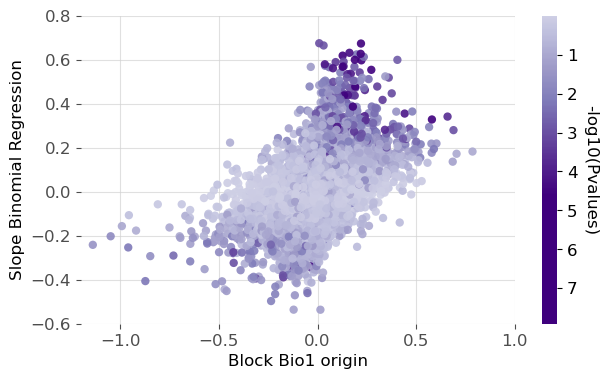

In [83]:
fig, ax = plt.subplots(figsize=(7, 4))

# Set grid to be behind scatterplot
plt.grid(True, color='lightgrey', alpha=0.7, zorder=0)

# First, plot non-significant points (grey dots)
sns.scatterplot(
    data=wza_binomial_regression_bio1,
    x='snp_origin_bio1',
    y='slope',
    hue='Z_pVal_log10',  # Use the density as color
    palette=new_cmap,  # Color mapping
    #s=50,  # Size for non-significant points
    edgecolor="none",  # Remove white edge around the dots
    alpha=0.9,  # Transparency for non-significant points
    ax=ax,
    zorder=1, # Higher zorder to ensure it's on top of the grid
    legend = False
)

# Plot the regression line using seaborn
#sns.regplot(
#    x='snp_origin_bio1',
#    y='slope',
#    data=non_significant,
#    scatter=False,  # Do not plot the scatter again
#    line_kws={"color": "green", "alpha": 0.7},  # Customize the regression line
#    ax=ax,
#    ci=None,  # Disable confidence interval
#)

# Set the x and y limits
ax.set_xlim([-1.2, 1])
ax.set_ylim([-0.6, 0.8])

plt.ylabel('Slope Binomial Regression')
plt.xlabel('Block Bio1 origin')


# Create a color normalization object for the p-values
norm = mcolors.Normalize(vmin=wza_binomial_regression_bio1['Z_pVal_log10'].min(), vmax=wza_binomial_regression_bio1['Z_pVal_log10'].max())
sm = plt.cm.ScalarMappable(cmap=new_cmap, norm=norm)
sm.set_array([])  # Only needed for older versions of matplotlib

# Add the color bar with reduced size and no borders
cbar = plt.colorbar(sm, ax=ax,)  # Adjust shrink value to make it smaller
cbar.set_label('-log10(Pvalues)', rotation=270, labelpad=15)  # Increase labelpad for more space
cbar.ax.invert_yaxis()  # Invert the color bar if needed
cbar.outline.set_visible(False)  # Remove border outline
#cbar.ax.set_position([0.8, 0.1, 0.02, 0.5])  # [left, bottom, width, height]


# Annotate the plot with slope, p-value, and R-squared
if p_value < 1e-3:
    p_value_text = "p-value < 1e-3"
else:
    p_value_text = f'P-value: {p_value:.3g}'

# Add the text box for the regression line info
#plt.text(
#    0.05, 0.9,  # X and Y position for annotation
#    f'Slope: {slope:.3f}\n{p_value_text}\n$R^2$: {r_squared:.3f}',  # Annotation text
#    fontsize=12, color="black",  # Font properties
#    ha='left', va='top',  # Text alignment
#    transform=ax.transAxes  # Ensure it's positioned relative to the axes
#)

#plt.rc('font', family='sans-serif', size=font_size)  # Regular font size
#plt.rc('axes', titlesize=font_size, labelsize=font_size)  # Title and label size for axes
#plt.rc('xtick', labelsize=font_size)  # X tick labels size
#plt.rc('ytick', labelsize=font_size)  # Y tick labels size

dark_grey = '#4D4D4D'  # Define dark grey color
plt.grid(True, color='lightgrey', alpha=0.7, zorder=0)

# Apply to spines
plt.gca().spines['left'].set_visible(False)
plt.gca().spines['bottom'].set_visible(False)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

# Set tick parameters
plt.tick_params(axis='both', colors=dark_grey)  # Set tick colors


plt.savefig("blocks_Across_space_nosignificantone.png")  # Save as SVG
plt.savefig("blocks_Across_space_nosignificantone.pdf", format='pdf')  # Save as SVG
# Save and show the plot
# plt.savefig('snp_origin_across_space_alpha_size_significant_layered.png')
plt.show()


In [359]:
print(p_value)

0.0


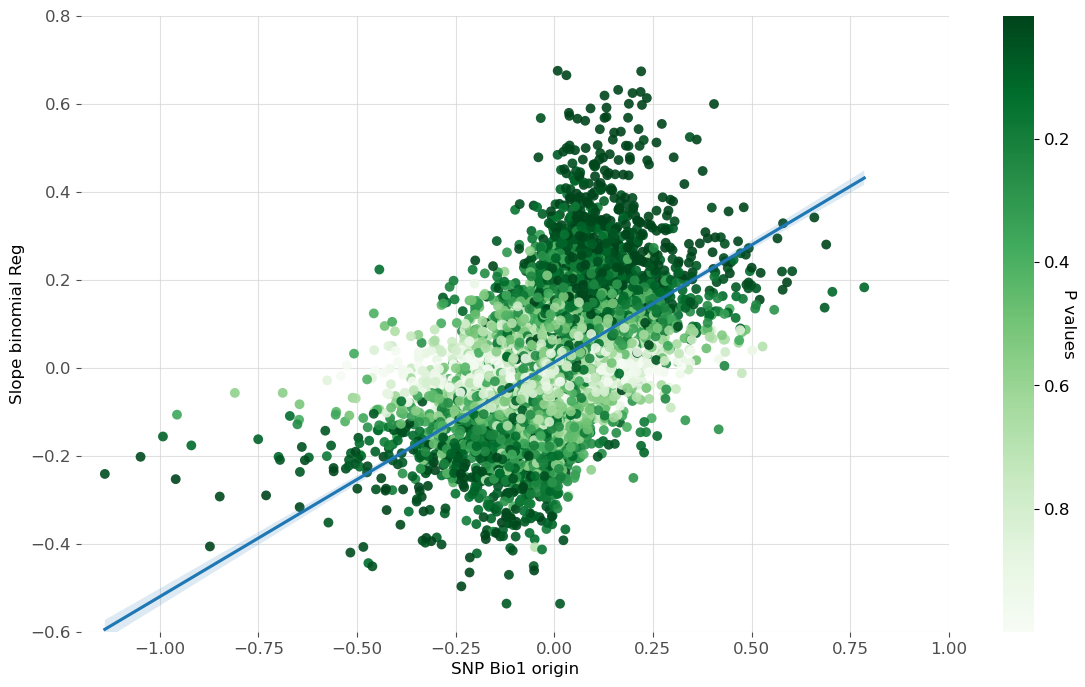

In [350]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
#plt.rcParams['axes.axisbelow'] = True
# Example DataFrames (for illustration purposes)
# non_significant = pd.DataFrame({'snp_origin_bio1': [...], 'slope': [...], 'Z_pVal': [...]})
# significant = pd.DataFrame({'snp_origin_bio1': [...], 'slope': [...], 'color': [...]})

fig, ax = plt.subplots(figsize=(14, 8))

# Set grid to be behind scatterplot
plt.grid(True, color='lightgrey', alpha=0.7, zorder=0)

# First, plot non-significant points (grey dots)
sns.scatterplot(
    data=wza_binomial_regression_bio1,
    x='snp_origin_bio1',
    y='slope',
    hue='Z_pVal',  # Use the density as color
    palette="Greens_r",  # Color mapping
    s=50,  # Size for non-significant points
    edgecolor="none",  # Remove white edge around the dots
    alpha=0.9,  # Transparency for non-significant points
    ax=ax,
    zorder=1, # Higher zorder to ensure it's on top of the grid
    legend = False
)



# Set the x and y limits
ax.set_xlim([-1.2, 1])
ax.set_ylim([-0.6, 0.8])

plt.ylabel('Slope binomial Reg')
plt.xlabel('SNP Bio1 origin')


# Create a color normalization object for the p-values
norm = mcolors.Normalize(vmin=non_significant['Z_pVal'].min(), vmax=non_significant['Z_pVal'].max())
sm = plt.cm.ScalarMappable(cmap="Greens_r", norm=norm)
sm.set_array([])  # Only needed for older versions of matplotlib

# Add the color bar with reduced size and no borders
cbar = plt.colorbar(sm, ax=ax,)  # Adjust shrink value to make it smaller
cbar.set_label('P values', rotation=270)
cbar.ax.invert_yaxis()  # Invert the color bar if needed
cbar.outline.set_visible(False)  # Remove border outline
#cbar.ax.set_position([0.8, 0.1, 0.02, 0.5])  # [left, bottom, width, height]

plt.rc('font', family='sans-serif', size=font_size)  # Regular font size
plt.rc('axes', titlesize=font_size, labelsize=font_size)  # Title and label size for axes
plt.rc('xtick', labelsize=font_size)  # X tick labels size
plt.rc('ytick', labelsize=font_size)  # Y tick labels size

dark_grey = '#4D4D4D'  # Define dark grey color
plt.grid(True, color='lightgrey', alpha=0.7, zorder=0)

# Apply to spines
plt.gca().spines['left'].set_visible(False)
plt.gca().spines['bottom'].set_visible(False)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

# Set tick parameters
plt.tick_params(axis='both', colors=dark_grey)  # Set tick colors


#plt.savefig("blocks_Across_space.png")  # Save as SVG
#plt.savefig("blocks_Across_space.svg", format='svg')  # Save as SVG
# Save and show the plot
# plt.savefig('snp_origin_across_space_alpha_size_significant_layered.png')
plt.show()


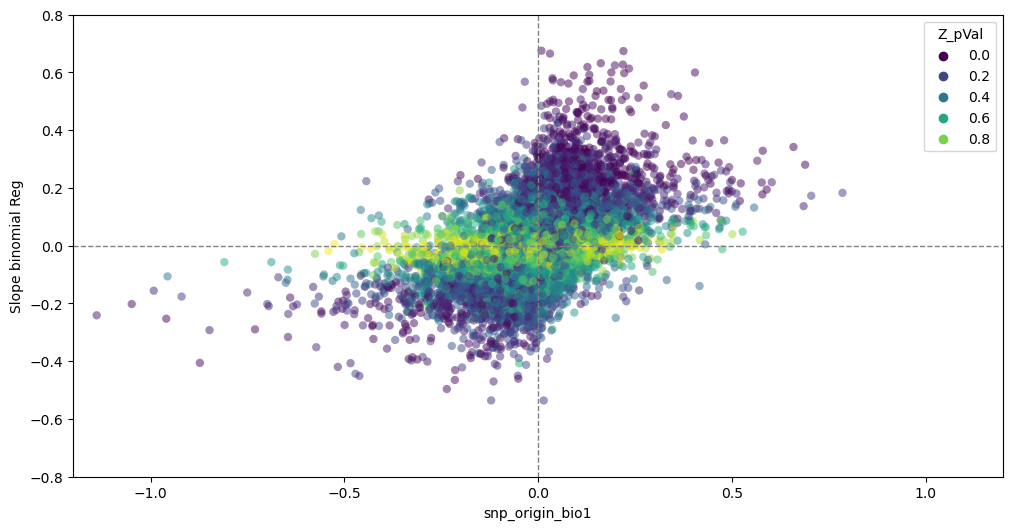

In [96]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Assuming snp_origin_beta_binomial_reg is your DataFrame with SNP data

# Create a scatter plot using density for color
fig, ax = plt.subplots(figsize=(12, 6))
sns.scatterplot(
    data=wza_binomial_regression_bio1,
    x='snp_origin_bio1',
    y='slope',
    hue='Z_pVal',  # Use the density as color
    palette="viridis",  # Color mapping
    edgecolor="none",  # Remove white edge around the dots
    alpha=0.5,  # Set transparency
    ax=ax
)
ax.axhline(0, color='grey', linestyle='--', linewidth=1)
ax.axvline(0, color='grey', linestyle='--', linewidth=1)

ax.set_xlim([-1.2, 1.2])
ax.set_ylim([-0.8, 0.8])

# Add a color bar to show the density scale
#fig.colorbar(sm, ax=ax, label='Pvalue')
plt.ylabel('Slope binomial Reg')
# Display the plot
plt.savefig('snp_origin_across_space.png')

plt.show()

In [99]:
snp_origin_beta_lfmm_s = snp_origin_beta_lfmm.sample(10000)